# 06 - Final Model Evaluation

Phases 13-16 of the project: hyperparameter tuning of the two models
shortlisted in notebook 05 (CatBoost, HistGradientBoosting), a single final
evaluation on the untouched test set, model explainability, and saving the
final deployable pipeline.

## 1. Setup

In [1]:
%matplotlib inline
import sys
import json
import time
from pathlib import Path
from datetime import datetime, timezone

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
from sklearn.model_selection import RandomizedSearchCV, KFold
from sklearn.metrics import mean_absolute_error, mean_squared_error, r2_score
from sklearn.inspection import permutation_importance


def find_project_root(start: Path) -> Path:
    for parent in [start, *start.parents]:
        if (parent / "src").is_dir() and (parent / "data").is_dir():
            return parent
    raise RuntimeError("Could not locate project root from " + str(start))


PROJECT_ROOT = find_project_root(Path.cwd())
if str(PROJECT_ROOT) not in sys.path:
    sys.path.insert(0, str(PROJECT_ROOT))

sns.set_theme(style="whitegrid")
pd.set_option("display.max_columns", None)
pd.set_option("display.width", 160)

from src.config import TRAINING_DATA_DIR, REPORTS_DIR, FIGURES_DIR, MODELS_DIR, RANDOM_SEED
from src.training.train_models import prepare_features, build_pipeline, rmse_score

feature_config = json.loads((TRAINING_DATA_DIR / "feature_config.json").read_text(encoding="utf-8"))
FEATURE_COLUMNS = feature_config["feature_columns"]
TARGET_COLUMN = feature_config["target_column"]

train_set = pd.read_csv(TRAINING_DATA_DIR / "train_set.csv")
test_set = pd.read_csv(TRAINING_DATA_DIR / "test_set.csv")
train_set = prepare_features(train_set)
test_set = prepare_features(test_set)

X_train, y_train = train_set[FEATURE_COLUMNS], train_set[TARGET_COLUMN]
X_test, y_test = test_set[FEATURE_COLUMNS], test_set[TARGET_COLUMN]
print("Train:", X_train.shape, " Test (untouched until Section 4):", X_test.shape)

Train: (4800, 19)  Test (untouched until Section 4): (1200, 19)


## 2. Hyperparameter Tuning (Phase 13)

`RandomizedSearchCV` (not an exhaustive grid, to avoid overfitting the
validation process) over the two models shortlisted in notebook 05, still
using only the training set.

In [2]:
from sklearn.ensemble import HistGradientBoostingRegressor
from catboost import CatBoostRegressor

cv = KFold(n_splits=5, shuffle=True, random_state=RANDOM_SEED)

search_space = {
    "HistGradientBoosting": {
        "model__max_iter": [100, 200, 300, 500],
        "model__max_depth": [None, 3, 5, 8],
        "model__learning_rate": [0.03, 0.05, 0.1, 0.2],
        "model__max_leaf_nodes": [15, 31, 63, 127],
        "model__l2_regularization": [0.0, 0.1, 1.0, 5.0],
        "model__min_samples_leaf": [10, 20, 30, 50],
    },
    "CatBoost": {
        "model__iterations": [200, 400, 600],
        "model__depth": [4, 6, 8, 10],
        "model__learning_rate": [0.03, 0.05, 0.1, 0.2],
        "model__l2_leaf_reg": [1, 3, 5, 10],
    },
}

baseline_models = {
    "HistGradientBoosting": HistGradientBoostingRegressor(random_state=RANDOM_SEED),
    "CatBoost": CatBoostRegressor(random_state=RANDOM_SEED, verbose=False),
}

n_iter_by_model = {"HistGradientBoosting": 30, "CatBoost": 15}

In [3]:
tuning_results = {}
for name, model in baseline_models.items():
    pipeline = build_pipeline(model)
    search = RandomizedSearchCV(
        pipeline,
        param_distributions=search_space[name],
        n_iter=n_iter_by_model[name],
        cv=cv,
        scoring="neg_mean_absolute_error",
        random_state=RANDOM_SEED,
        n_jobs=-1,
        refit=True,
    )
    start = time.time()
    search.fit(X_train, y_train)
    elapsed = time.time() - start
    tuning_results[name] = search
    print(f"{name}: best CV MAE = {-search.best_score_:,.0f} EGP ({elapsed:.1f}s, {n_iter_by_model[name]} iterations)")
    print(f"  best params: {search.best_params_}")

HistGradientBoosting: best CV MAE = 7,043 EGP (34.6s, 30 iterations)
  best params: {'model__min_samples_leaf': 10, 'model__max_leaf_nodes': 31, 'model__max_iter': 500, 'model__max_depth': 3, 'model__learning_rate': 0.05, 'model__l2_regularization': 5.0}


CatBoost: best CV MAE = 6,908 EGP (103.5s, 15 iterations)
  best params: {'model__learning_rate': 0.05, 'model__l2_leaf_reg': 10, 'model__iterations': 600, 'model__depth': 4}


## 3. Baseline vs Tuned Comparison

In [4]:
baseline_cv_mae = {"CatBoost": 6978.53, "HistGradientBoosting": 7263.39}  # from notebooks/05 (reports/05_model_comparison.csv)

improvement_rows = []
for name, search in tuning_results.items():
    tuned_mae = -search.best_score_
    improvement_rows.append({
        "Model": name,
        "Baseline_CV_MAE": baseline_cv_mae[name],
        "Tuned_CV_MAE": tuned_mae,
        "Improvement_EGP": baseline_cv_mae[name] - tuned_mae,
        "Improvement_Pct": 100 * (baseline_cv_mae[name] - tuned_mae) / baseline_cv_mae[name],
    })
improvement_df = pd.DataFrame(improvement_rows)
improvement_df

,Model,Baseline_CV_MAE,Tuned_CV_MAE,Improvement_EGP,Improvement_Pct
0,HistGradientBoosting,7263.39,7042.793868,220.596132,3.037096
1,CatBoost,6978.53,6907.502648,71.027352,1.017798


## 4. Final Model Selection and Test-Set Evaluation (Phase 14)

This is the **only** cell in the whole project that scores predictions against the held-out test set.

In [5]:
final_model_name = improvement_df.sort_values("Tuned_CV_MAE").iloc[0]["Model"]
final_pipeline = tuning_results[final_model_name].best_estimator_

y_pred_test = final_pipeline.predict(X_test)

final_metrics = {
    "MAE": mean_absolute_error(y_test, y_pred_test),
    "RMSE": rmse_score(y_test, y_pred_test),
    "R2": r2_score(y_test, y_pred_test),
}
print("Final model:", final_model_name)
final_metrics

Final model: CatBoost


{'MAE': 6545.552673638108, 'RMSE': 8626.549362387452, 'R2': 0.9856381491889781}

**Interpretation:** on apartments the model has never seen, the average
absolute prediction error (MAE) and the typical relative error (MAE as a
% of the mean total cost) are printed below in plain EGP terms.

In [6]:
mean_cost = y_test.mean()
print(f"MAE  = {final_metrics['MAE']:,.0f} EGP -> the average absolute prediction error is about {final_metrics['MAE']:,.0f} EGP")
print(f"RMSE = {final_metrics['RMSE']:,.0f} EGP (penalises larger misses more than MAE)")
print(f"R2   = {final_metrics['R2']:.4f} -> the model explains {final_metrics['R2']*100:.1f}% of the variance in total finishing cost")
print(f"MAE as a share of the average total cost ({mean_cost:,.0f} EGP): {100*final_metrics['MAE']/mean_cost:.1f}%")

MAE  = 6,546 EGP -> the average absolute prediction error is about 6,546 EGP
RMSE = 8,627 EGP (penalises larger misses more than MAE)
R2   = 0.9856 -> the model explains 98.6% of the variance in total finishing cost
MAE as a share of the average total cost (238,696 EGP): 2.7%


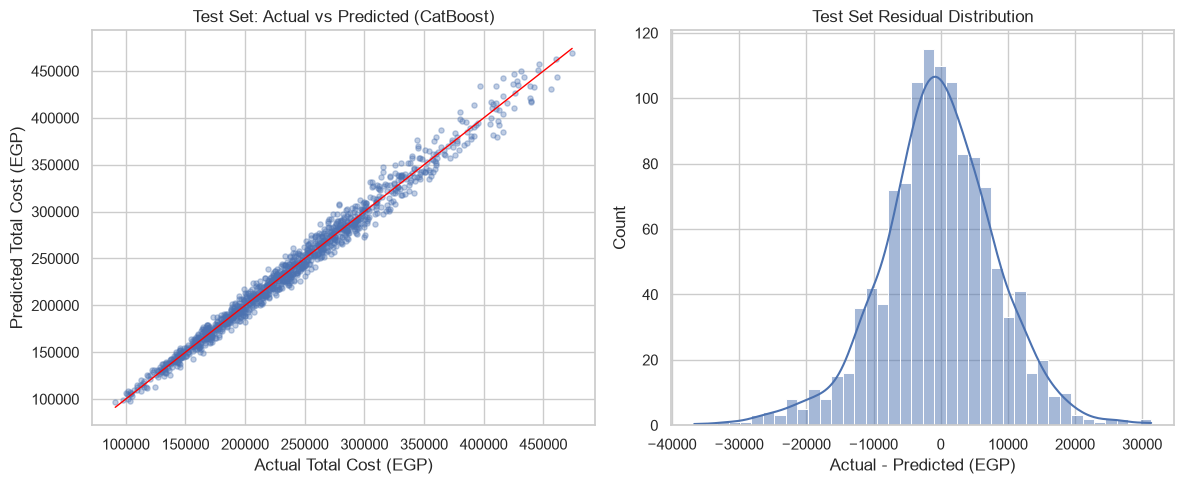

In [7]:
fig, axes = plt.subplots(1, 2, figsize=(12, 5))
axes[0].scatter(y_test, y_pred_test, alpha=0.35, s=14)
lims = [y_test.min(), y_test.max()]
axes[0].plot(lims, lims, color="red", linewidth=1)
axes[0].set_xlabel("Actual Total Cost (EGP)")
axes[0].set_ylabel("Predicted Total Cost (EGP)")
axes[0].set_title(f"Test Set: Actual vs Predicted ({final_model_name})")

test_residuals = y_test.values - y_pred_test
sns.histplot(test_residuals, bins=40, kde=True, ax=axes[1])
axes[1].set_title("Test Set Residual Distribution")
axes[1].set_xlabel("Actual - Predicted (EGP)")

plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_final_model_test_performance.png", dpi=120)
plt.show()

*Performance by apartment area, finishing level, and cost range on the test set:*

In [8]:
test_diag = X_test.copy()
test_diag["Actual"] = y_test.values
test_diag["Predicted"] = y_pred_test
test_diag["Abs_Error"] = np.abs(test_diag["Actual"] - test_diag["Predicted"])
test_diag["Pct_Error"] = 100 * test_diag["Abs_Error"] / test_diag["Actual"]

area_bins = pd.cut(test_diag["Apartment_Area_m2"], bins=[0, 90, 130, 170, 300],
                    labels=["<=90", "90-130", "130-170", ">170"])
by_area = test_diag.groupby(area_bins)[["Abs_Error", "Pct_Error"]].mean()
by_level = test_diag.groupby("Finishing_Level")[["Abs_Error", "Pct_Error"]].mean().reindex(["Low", "Medium", "High"])
cost_bins = pd.qcut(test_diag["Actual"], q=4)
by_cost = test_diag.groupby(cost_bins)[["Abs_Error", "Pct_Error"]].mean()

print("By apartment area:"); print(by_area)
print("\nBy finishing level:"); print(by_level)
print("\nBy cost quartile:"); print(by_cost)

By apartment area:
                      Abs_Error  Pct_Error
Apartment_Area_m2                         
<=90                4158.846577   2.652130
90-130              6192.183708   2.689391
130-170             7875.757238   2.695052
>170               12059.603837   3.297586

By finishing level:
                   Abs_Error  Pct_Error
Finishing_Level                        
Low              6508.580420   2.951422
Medium           6364.658861   2.696253
High             6923.944866   2.540696

By cost quartile:
                            Abs_Error  Pct_Error
Actual                                          
(91205.469, 184090.53]    4135.525995   2.729435
(184090.53, 233400.375]   5459.689094   2.616755
(233400.375, 282128.415]  7179.433741   2.793701
(282128.415, 474146.71]   9407.561864   2.796140


C:\Users\a\AppData\Local\Temp\ipykernel_29984\3524187212.py:9: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_area = test_diag.groupby(area_bins)[["Abs_Error", "Pct_Error"]].mean()
C:\Users\a\AppData\Local\Temp\ipykernel_29984\3524187212.py:12: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.
  by_cost = test_diag.groupby(cost_bins)[["Abs_Error", "Pct_Error"]].mean()


## 5. Model Explainability (Phase 15)

In [9]:
preprocessor = final_pipeline.named_steps["preprocessor"]
model = final_pipeline.named_steps["model"]
feature_names = preprocessor.get_feature_names_out()

if hasattr(model, "feature_importances_"):
    native_importance = pd.Series(model.feature_importances_, index=feature_names).sort_values(ascending=False)
    print("Native feature importance (top 15):")
    print(native_importance.head(15))
else:
    native_importance = None
    print(f"{final_model_name} has no native feature_importances_ attribute; relying on permutation importance below.")

Native feature importance (top 15):
numeric__Apartment_Area_m2                    48.926522
numeric__Rooms                                24.153285
numeric__Include_Reception_Ceiling_Upgrade    12.781055
numeric__Bathrooms                             5.009538
categorical__Finishing_Level_High              2.754747
categorical__Finishing_Level_Low               1.104005
numeric__Balconies                             0.982112
numeric__Include_Master_Bathroom_Upgrade       0.808414
categorical__Ceilings_Quality_High             0.749014
categorical__Paints_Quality_Low                0.740827
categorical__Paints_Quality_High               0.682272
categorical__Sanitary_Quality_High             0.439136
categorical__Doors_Quality_Low                 0.305078
categorical__Ceilings_Quality_Low              0.173558
categorical__Doors_Quality_High                0.093791
dtype: float64


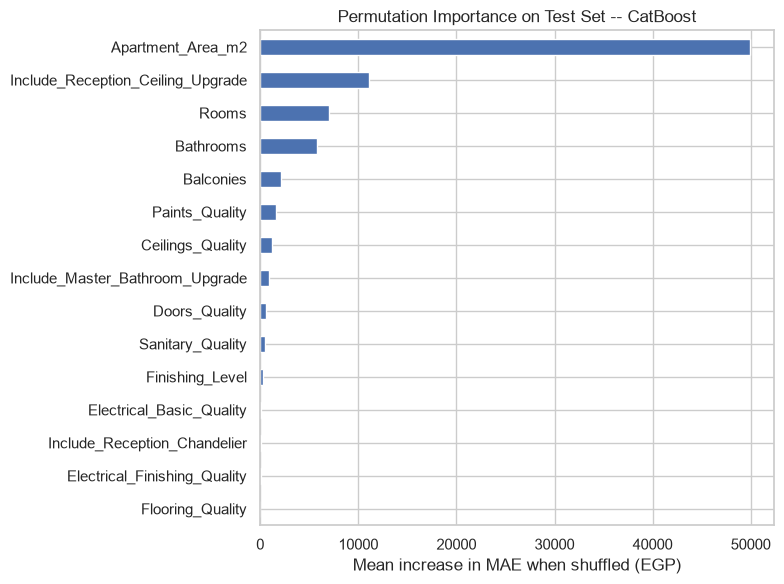

Apartment_Area_m2                    49879.014918
Include_Reception_Ceiling_Upgrade    11109.437508
Rooms                                 7018.660694
Bathrooms                             5766.205471
Balconies                             2156.387535
Paints_Quality                        1571.329947
Ceilings_Quality                      1185.351893
Include_Master_Bathroom_Upgrade        884.191855
Doors_Quality                          591.415053
Sanitary_Quality                       493.785165
Finishing_Level                        239.384415
Electrical_Basic_Quality                66.691397
Include_Reception_Chandelier            58.206003
Electrical_Finishing_Quality            32.039933
Flooring_Quality                         3.522044
dtype: float64

In [10]:
perm_result = permutation_importance(
    final_pipeline, X_test, y_test, n_repeats=10, random_state=RANDOM_SEED, scoring="neg_mean_absolute_error", n_jobs=-1
)
perm_importance = pd.Series(perm_result.importances_mean, index=FEATURE_COLUMNS).sort_values(ascending=False)

plt.figure(figsize=(8, 6))
perm_importance.head(15).sort_values().plot(kind="barh")
plt.xlabel("Mean increase in MAE when shuffled (EGP)")
plt.title(f"Permutation Importance on Test Set -- {final_model_name}")
plt.tight_layout()
plt.savefig(FIGURES_DIR / "06_permutation_importance.png", dpi=120)
plt.show()

perm_importance.head(15)

**Leakage sanity check:** the most important features should be exactly
the ones domain knowledge predicts (apartment area/rooms/bathrooms and the
per-category quality preferences) -- not an arbitrary or suspiciously
perfect single feature. `Apartment_Area_m2` dominating is expected: nearly
every category's quantity is a function of area.

In [11]:
top_feature = perm_importance.index[0]
print("Top feature by permutation importance:", top_feature)
assert top_feature in {"Apartment_Area_m2", "Rooms"}, "Unexpected top feature -- investigate for leakage"
print("OK -- top feature is a legitimate apartment-characteristic input, not a suspicious proxy for the target.")

Top feature by permutation importance: Apartment_Area_m2
OK -- top feature is a legitimate apartment-characteristic input, not a suspicious proxy for the target.


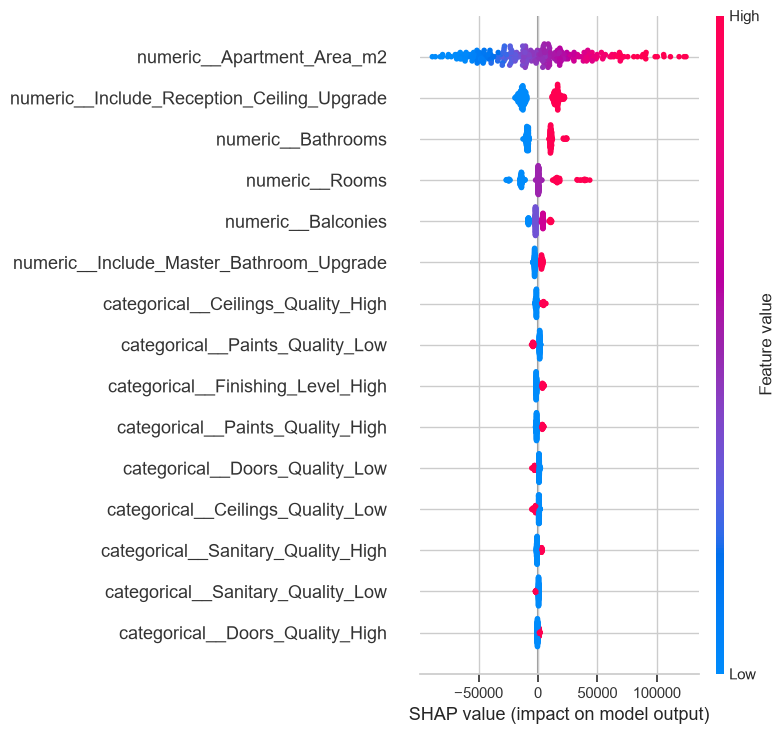

SHAP summary plot saved to reports/figures/06_shap_summary.png


In [12]:
try:
    import shap

    X_test_transformed = preprocessor.transform(X_test)
    if hasattr(X_test_transformed, "toarray"):
        X_test_transformed = X_test_transformed.toarray()
    X_test_transformed_df = pd.DataFrame(X_test_transformed, columns=feature_names)

    explainer = shap.TreeExplainer(model)
    shap_values = explainer.shap_values(X_test_transformed_df.iloc[:300])

    shap.summary_plot(shap_values, X_test_transformed_df.iloc[:300], show=False, max_display=15)
    plt.tight_layout()
    plt.savefig(FIGURES_DIR / "06_shap_summary.png", dpi=120)
    plt.show()
    print("SHAP summary plot saved to reports/figures/06_shap_summary.png")
except Exception as exc:
    print(f"SHAP explanation skipped ({type(exc).__name__}: {exc}). "
          "Permutation importance above remains the primary explainability evidence.")

### 5.1 Empirical Residual Quantiles (for a statistically-grounded prediction range)

Phase 19 asks for a prediction range only if the methodology supports it
statistically, and explicitly forbids inventing confidence intervals. The
range used later by `predict_finishing_cost` is therefore the **empirical
5th/95th percentile of the residuals observed on this held-out test set**
-- i.e. an approximate 90% empirical coverage interval around the point
prediction, computed from real out-of-sample errors rather than assumed.

In [13]:
residual_quantiles = {
    "p05": float(np.quantile(test_residuals, 0.05)),
    "p95": float(np.quantile(test_residuals, 0.95)),
}
print("90% empirical residual band (Actual - Predicted):", residual_quantiles)

90% empirical residual band (Actual - Predicted): {'p05': -14682.391808114897, 'p95': 13112.248012749886}


## 6. Save the Final Model (Phase 16)

In [14]:
MODELS_DIR.mkdir(parents=True, exist_ok=True)

model_path = MODELS_DIR / "final_model_pipeline.joblib"
joblib.dump(final_pipeline, model_path)

metadata = {
    "model_name": final_model_name,
    "model_version": "1.0.0",
    "trained_at_utc": datetime.now(timezone.utc).isoformat(),
    "random_seed": RANDOM_SEED,
    "feature_columns": FEATURE_COLUMNS,
    "target_column": TARGET_COLUMN,
    "best_params": tuning_results[final_model_name].best_params_,
    "test_set_metrics": final_metrics,
    "test_set_residual_quantiles": residual_quantiles,
    "training_rows": int(len(X_train)),
    "test_rows": int(len(X_test)),
    "training_data": "scenario-generated / synthetic (see src/scenario_generation/generate_scenarios.py)",
    "notes": (
        "Single sklearn Pipeline containing the full preprocessing "
        "(imputation + one-hot encoding + scaling) and the tuned regressor. "
        "Load with joblib.load and call .predict on a DataFrame with exactly "
        "the columns listed in feature_columns."
    ),
}
metadata_path = MODELS_DIR / "model_metadata.json"
metadata_path.write_text(json.dumps(metadata, indent=2), encoding="utf-8")

print("Saved", model_path)
print("Saved", metadata_path)

Saved F:\Instant\DataAnalysis\Gradution Project\All data\_staging\models\final_model_pipeline.joblib
Saved F:\Instant\DataAnalysis\Gradution Project\All data\_staging\models\model_metadata.json


In [15]:
# Sanity-reload check: the saved artifact must be usable stand-alone.
reloaded = joblib.load(model_path)
sample = X_test.iloc[:3]
print(reloaded.predict(sample))
print(y_test.iloc[:3].values)

[194980.16960116 197030.11095859 262572.30370961]
[188372.43 198328.18 263378.97]


In [16]:
report_path = REPORTS_DIR / "06_final_model_report.md"
lines = ["# Final Model Evaluation Report", ""]
lines.append("Generated by `notebooks/06_Final_Model_Evaluation.ipynb`. Do not edit by hand.")
lines.append("")
lines.append(f"## Final model: {final_model_name}")
lines.append("")
lines.append(f"Best hyperparameters: `{tuning_results[final_model_name].best_params_}`")
lines.append("")
lines.append("## Baseline vs tuned (cross-validated MAE, training set)")
lines.append("")
lines.append(improvement_df.round(2).to_markdown(index=False))
lines.append("")
lines.append("## Test-set performance (evaluated once, held out until this point)")
lines.append("")
for k, v in final_metrics.items():
    lines.append(f"- **{k}**: {v:,.2f}")
lines.append(f"- MAE as % of mean test-set cost ({mean_cost:,.0f} EGP): {100*final_metrics['MAE']/mean_cost:.1f}%")
lines.append(f"- 90% empirical residual band: [{residual_quantiles['p05']:,.0f}, {residual_quantiles['p95']:,.0f}] EGP around the point prediction")
lines.append("")
lines.append("## Top 15 features by permutation importance (test set)")
lines.append("")
lines.append(perm_importance.head(15).to_frame("Mean_MAE_Increase_EGP").to_markdown())
lines.append("")
lines.append(f"Model saved to `models/final_model_pipeline.joblib`, metadata in `models/model_metadata.json`.")

report_path.write_text("\n".join(lines), encoding="utf-8")
print("Saved", report_path)

Saved F:\Instant\DataAnalysis\Gradution Project\All data\_staging\reports\06_final_model_report.md
